In [3]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator, FixedFormatter
import csv

from common import make_canvas

Compress trainds figures

In [28]:
d = 10_000  # train size
dstop = 1_000 # compressed training dataset size
k = 5
train_noise = 3.0
test_size = 100_000
hidden_dim = 50
epochs = 400
batch_size = None

algo_name = 'AdamW'
lr = 0.01

plot_every = 10

filename = f'CPTDS/teacher_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_hidden{hidden_dim}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

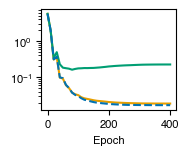

In [29]:
fig, axs = make_canvas(rows=1, cols=1, axes_width_pt=80, axes_aspect=0.75, sharex=True, gridspec_kw={'hspace': 0})

axs.plot(epoch_range, test_loss_cp, color="#E69F00", marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs.plot(epoch_range, test_loss_naive, color="#009E73", marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs.plot(epoch_range, test_loss_orig,  color="#0072B2", marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs.set_xlabel('Epoch')
axs.set_yscale('log')
# axs.legend()

# # enforce ticks at only 0.01 and 0.02
# yticks = [0.01, 0.02]
# axs[1].yaxis.set_major_locator(FixedLocator(yticks))
# # axs[1].yaxis.set_major_formatter(FixedFormatter([f"{t:.2f}" for t in yticks]))
# axs[1].yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()